Imports

In [1]:
import generate_training
import Multi_loop
import time
from glob import glob
from LightPipes import * 
import torch
import pickle as pkl
import json
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.transforms import v2
from mode_classifier import ResNet, ResidualBlock
import modes
from tqdm import tqdm as tqdm
from pickle_Dataset import pickle_Dataset
import gc
from torch.cuda.amp import autocast, GradScaler

Customize Training data

In [2]:
mode_params = [
    {'mode': [0,0], 'LG': False, 'angle': 0, 'diameter': [170*um, 220*um]},
    {'mode': [0,1], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]}, 
    {'mode': [0,2], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]},    
    {'mode': [0,3], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]}, 
    {'mode': [0,4], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]},
    {'mode': [0,5], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]}, 
    {'mode': [0,6], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]},
    {'mode': [0,7], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]},
    {'mode': [0,8], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]}, 
    {'mode': [0,9], 'LG': False, 'angle': 90, 'diameter': [180*um, 250*um]},

    # {'mode': [0,6], 'LG': True, 'angle': 70+90, 'diameter': [150*um, 150*um]},
    # {'mode': [0,9], 'LG': False, 'angle': 70+90, 'diameter': False}  
]

In [3]:
# For models for confidence of each mode use modes.mode_func
# For model for bec or multi mode use modes.bec_multi
test_ims = generate_training.generate_data(
    10, 2500*um, 300, mode_params, [200*um, 200*um],
    fringe_size = [0.3,0.6], save=False, mult_las_split=0.5, 
    mode_func=modes.bec_multi, sigm = [0.05,0.05])

100%|██████████| 10/10 [00:04<00:00,  2.43it/s]


tensor([[0., 1.]])


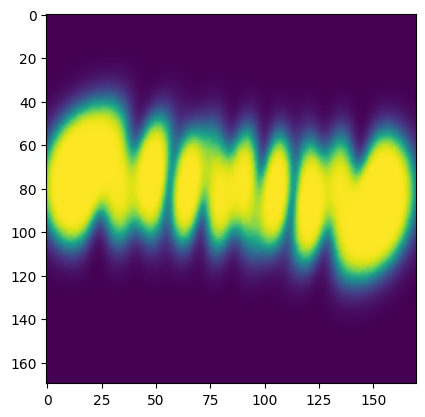

tensor([[1., 0.]])


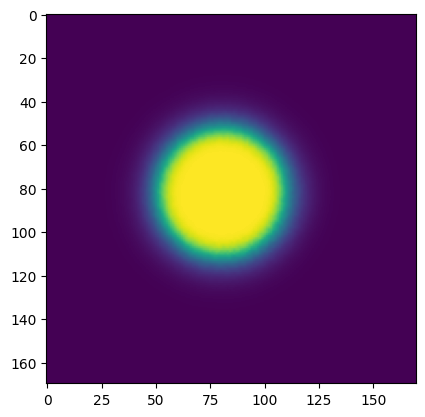

tensor([[1., 0.]])


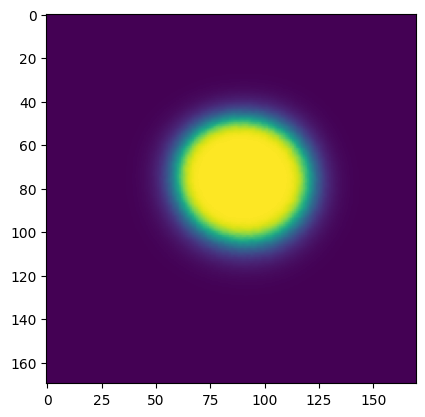

tensor([[1., 0.]])


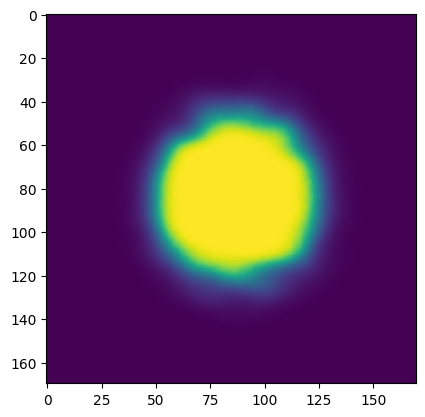

tensor([[0., 1.]])


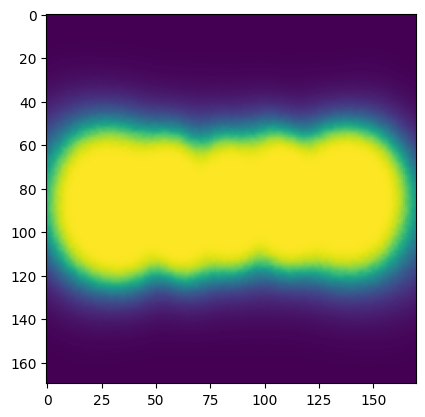

tensor([[0., 1.]])


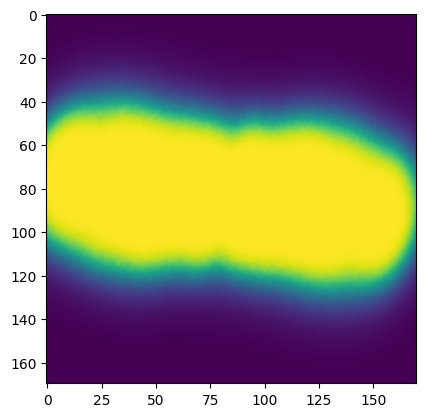

tensor([[0., 1.]])


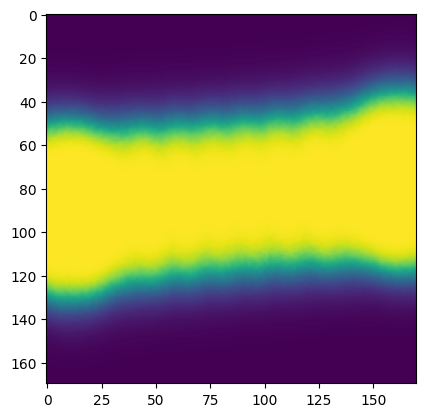

tensor([[1., 0.]])


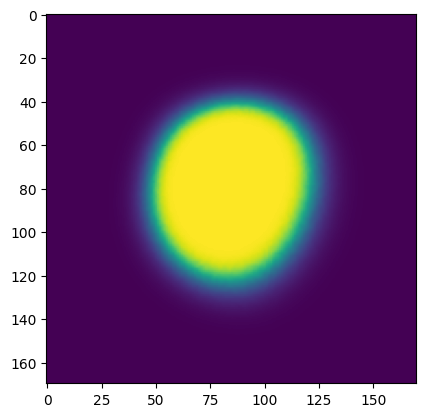

tensor([[0., 1.]])


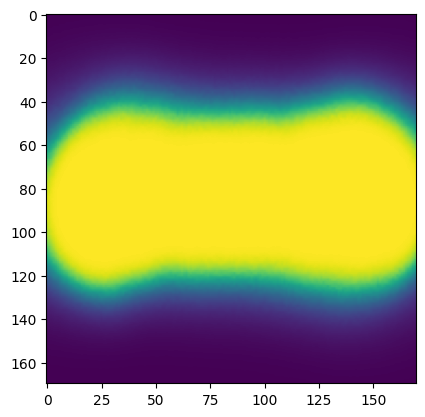

tensor([[0., 1.]])


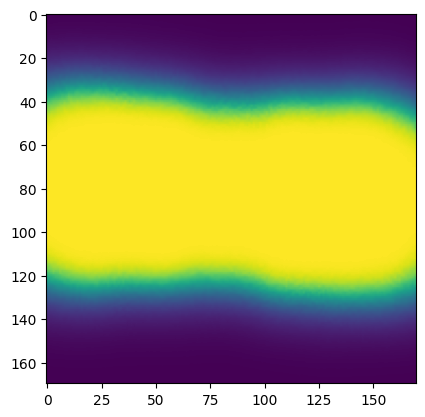

In [4]:
# %matplotlib qt
for img in test_ims:
    print(img[1])
    plt.imshow(img[0])
    plt.show()


Make sure that bec with sigmoid looks like training data

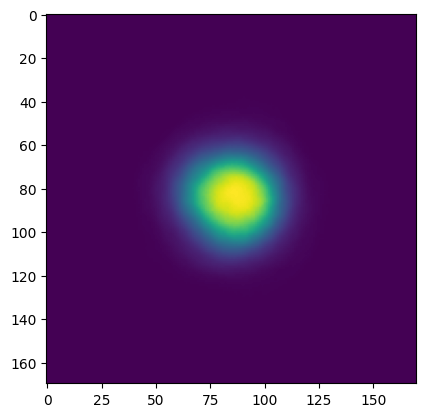

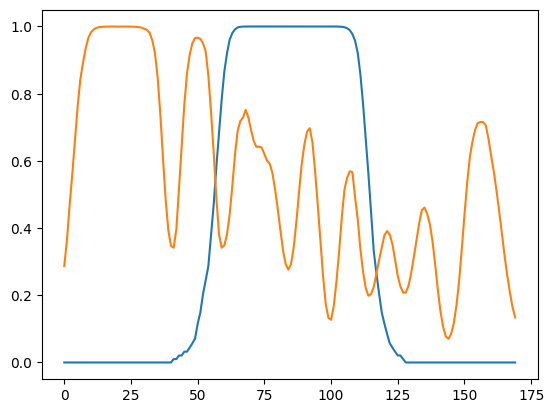

In [5]:
import cv2
import numpy as np
from scipy.ndimage import zoom
bec_im = cv2.imread(r"C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data\Cropped_Images\22_07_disp_1_crop\Croppbec_20240801_213649_4.0_0.06916934232619047_942.746337890625_-2.0_.png", 0)
bec_im = zoom(bec_im, len(test_ims[1][0])/np.array(bec_im.shape))
plt.imshow(bec_im)
plt.show()
bec_im = generate_training.quick_norm(bec_im)

bec_im = generate_training.sigmoid(bec_im, 0.05, 0.1)
bec_im = generate_training.quick_norm(bec_im)

plt.plot(bec_im[:,85])
img = generate_training.quick_norm(test_ims[0][0])
# img = generate_training.sigmoid(img, 0.05, 0.1)
img = generate_training.quick_norm(img)
max_arg = np.unravel_index(img.argmax(),img.shape)
plt.plot(img[max_arg[0]])
plt.show()

Generate Training Data

In [6]:
import subprocess
from subprocess import PIPE
import dill
import socket


save_dir = ''
bat_file = ''
# if socket.gethostname() == 'LOUIS_PC':
save_dir = r'C:\Users\Pouis\Documents\Uni Shit\Masters\Training Images'
bat_file = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\generate_training.bat'
num_threads = 15

save = True
num_ims = 30000

# ims = generate_training.generate_data_multithreaded(
#     num_threads, 128 // num_threads, 2500*um, 
#     500, mode_params, [160*um, 210*um], 
#     fringe_size=[0.5, 0.8], save=save, 
#     mult_las_split=0, save_dir=save_dir, mode_func = modes.bec_multi, sigm = [0.03, 0.2])
print(bat_file)
args = {
    'num_threads': num_threads, 'num': num_ims // num_threads, 'size': 2500*um, 'dim': 450, 'modes': mode_params,
    'w0': [160*um, 210*um], 'fringe_size': [], 'save': save, 'mult_las_split': 0.5, 'save_dir': save_dir, 'mode_func': modes.bec_multi,
    'sigm': [0.1, 0.1]
}
with open('training_params.dill', 'wb') as f:
    dill.dump(args, f)
 





C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\generate_training.bat


In [7]:
from os import remove
if save:
    for f in glob(save_dir + r'\*'):
        remove(f)
subprocess.run([bat_file], shell=True, creationflags=subprocess.CREATE_NEW_CONSOLE, stdin=PIPE, stderr=PIPE, stdout=PIPE)
input('Press Enter when done')

''

Set up model

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
# classes = len(generate_training.modelist) # for confidence
classes = 1 # for bec_multi
epochs = 30
criterion = torch.nn.CrossEntropyLoss()
learning_rate = 0.0000005
val_split = 0.2
batch_size = 32
best_accuracy = 0.0 

save_path = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\170824_multi_'

with open(save_path + 'mode_parameters.json', 'w') as f:
    json.dump(mode_params, f)

transform = v2.Compose([v2.ToTensor(), v2.Resize((224,224), antialias=True), v2.Normalize((0.5,), (
        0.5,))])


cuda


C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(


Create Training dataset

In [16]:
# Creates dataset of all images
train_dataset = pickle_Dataset(root = save_dir, transforms = transform)

# splits dataset into test and training data
numTrainSamp = round(len(train_dataset) * (1 - val_split))
numValSamp = len(train_dataset) - numTrainSamp
print(numTrainSamp, numValSamp)
(train_dataset, validate_dataset) = torch.utils.data.random_split(train_dataset, [int(numTrainSamp), int(numValSamp)],
                                                                                generator=None)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(dataset=validate_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

22881 5720


Train Model

In [17]:
for i in range(classes):
    model = ResNet(ResidualBlock, [2, 2, 2, 2], 2)

    # append_dropout(model)
    history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "val_loss": []
    }
    # optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum = 0)
    # runs Training loop
    model, history = Multi_loop.Training(model, epochs, i, optimizer, 
                                         train_loader, val_loader, history, 
                                         criterion=criterion, save_path=save_path)

    with open(save_path + f'{i}_' + 'history.json', 'w') as f:
        json.dump(history, f)

    del model

C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
Accuracy of the network on the validation images: 99.31818181818181 %: 100%|██████████| 30/30 [1:55:13<00:00, 230.45s/it]


Plot Histories

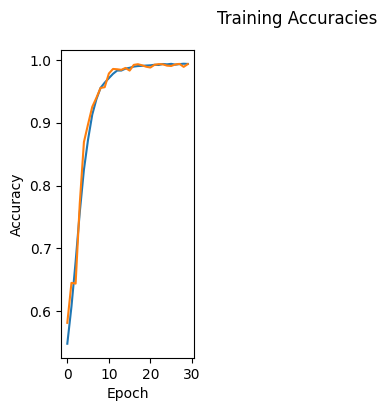

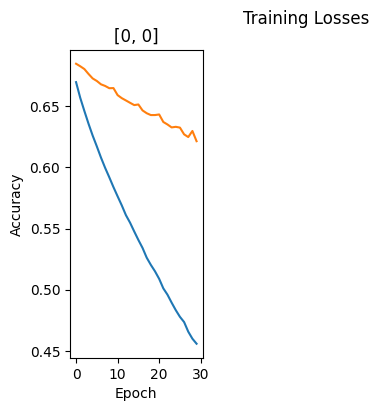

In [18]:
hist_files = glob(save_path + '*history*')

from power_length_analysis import grid_plot
from math import ceil

ncols = 3
fig, axes, gs = grid_plot(classes, ncols = ncols, nrows = ceil(classes/ncols), wspace=0.5)

for i, (hist, mp) in enumerate(zip(hist_files, mode_params)):
    with open(hist, 'r') as f:
        hist = json.load(f)
    l1 = axes[i].plot(hist['train_accuracy'], label = 'Training Accuracy')
    l2 = axes[i].plot(hist['val_accuracy'], label = 'Validation Accuracy')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
#     axes[i].set_title(mp['mode'])
# fig.legend(handles=[l1,l2])
fig.suptitle('Training Accuracies')
plt.show()

ncols = 3
fig, axes, gs = grid_plot(classes, ncols = ncols, nrows = ceil(classes/ncols), wspace=0.5)

for i, (hist, mp) in enumerate(zip(hist_files, mode_params)):
    with open(hist, 'r') as f:
        hist = json.load(f)
    l1 = axes[i].plot(hist['train_loss'], label = 'Training Loss')
    l2 = axes[i].plot(hist['val_loss'], label = 'Validation Loss')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes[i].set_title(mp['mode'])
# fig.legend(handles=[l1,l2])
fig.suptitle('Training Losses')
plt.show()

